In [1]:
import pandas as pd
import requests

In [2]:
url = "https://api.census.gov/data/2023/acs/acs1?get=NAME,B19083_001E&for=state:*"

data = requests.get(url).json()

data[:5]

[['NAME', 'B19083_001E', 'state'],
 ['Alabama', '0.4771', '01'],
 ['Alaska', '0.4492', '02'],
 ['Arizona', '0.4650', '04'],
 ['Arkansas', '0.4740', '05']]

In [3]:
df = pd.DataFrame(data[1:], columns=data[0])

df.head()

,NAME,B19083_001E,state
0,Alabama,0.4771,01
1,Alaska,0.4492,02
2,Arizona,0.4650,04
3,Arkansas,0.4740,05
4,California,0.4870,06


In [4]:
df = df.rename(columns={
    "NAME": "State",
    "B19083_001E": "Gini"
})

df["Year"] = 2023

df.head()

,State,Gini,state,Year
0,Alabama,0.4771,01,2023
1,Alaska,0.4492,02,2023
2,Arizona,0.4650,04,2023
3,Arkansas,0.4740,05,2023
4,California,0.4870,06,2023


In [7]:
import requests
print(requests.get("https://api.census.gov/data/2020/acs/").status_code)
print(requests.get("https://api.census.gov/data/2020/acs/").text[:500])

200
{
  "@context": "https://project-open-data.cio.gov/v1.1/schema/catalog.jsonld",
  "@id": "http://api.census.gov/data/2020/acs/acs5.json",
  "@type": "dcat:Catalog",
  "conformsTo": "https://project-open-data.cio.gov/v1.1/schema",
  "describedBy": "https://project-open-data.cio.gov/v1.1/schema/catalog.json",
  "dataset": [
    {
      "c_vintage": 2020,
      "c_dataset": [
        "acs",
        "acs5"
      ],
      "c_geographyLink": "http://api.census.gov/data/2020/acs/acs5/geography.json",
 


In [8]:
import requests
u = "https://api.census.gov/data/2020/acs/acs1/variables.json"
r = requests.get(u)
print(r.status_code, r.headers.get("content-type"))
print(r.text[:200])

404 text/html;charset=ISO-8859-1
<!doctype html><html lang="en"><head><title>HTTP Status 404 ? Not Found</title><style type="text/css">body {font-family:Tahoma,Arial,sans-serif;} h1, h2, h3, b {color:white;background-color:#525D76;} 


In [45]:
import pandas as pd
import requests
import os

def dataset_exists(year: int, dataset: str) -> bool:
    """Check if a dataset name (e.g., 'acs1') exists under /data/{year}/acs/ directory listing."""
    r = requests.get(f"https://api.census.gov/data/{year}/acs/", timeout=30)
    if r.status_code != 200:
        return False
    return dataset.lower() in r.text.lower()

def fetch_json(url: str):
    r = requests.get(url, timeout=30)
    if r.status_code != 200:
        raise RuntimeError(f"HTTP {r.status_code}: {url}\n{text_preview(r.text)}")
    # 有时会返回 html，保险起见检查一下
    ct = (r.headers.get("content-type") or "").lower()
    if "application/json" not in ct:
        raise RuntimeError(f"Non-JSON response ({ct}): {url}\n{text_preview(r.text)}")
    return r.json()

def text_preview(txt, n=200):
    return (txt or "")[:n].replace("\n"," ")

years = list(range(2015, 2024))  # 2015–2023
valid_years = [y for y in years if dataset_exists(y, "acs1")]
print("Valid ACS1 years:", valid_years)

# ---------- 1) Gini (B19083_001E) ----------
gini_dfs = []
for y in valid_years:
    url = f"https://api.census.gov/data/{y}/acs/acs1?get=NAME,B19083_001E&for=state:*"
    data = fetch_json(url)
    df = pd.DataFrame(data[1:], columns=data[0])
    df = df.rename(columns={"NAME":"State", "B19083_001E":"Gini", "state":"state_fips"})
    df["Year"] = y
    gini_dfs.append(df)
gini = pd.concat(gini_dfs, ignore_index=True)
gini.to_csv("raw_data/acs_gini_raw.csv", index=False)
# ---------- 2) College % (S1501_C02_015E) ----------
# 注意：S1501 是 Subject table，用 /subject
college_dfs = []
for y in valid_years:
    url = f"https://api.census.gov/data/{y}/acs/acs1/subject?get=NAME,S1501_C02_015E&for=state:*"
    data = fetch_json(url)
    df = pd.DataFrame(data[1:], columns=data[0])
    df = df.rename(columns={"NAME":"State", "S1501_C02_015E":"College", "state":"state_fips"})
    df["Year"] = y
    college_dfs.append(df)
college = pd.concat(college_dfs, ignore_index=True)
college.to_csv("raw_data/acs_college_raw.csv", index=False)
# ---------- 3) merge ----------
acs = pd.merge(
    gini[["State","state_fips","Year","Gini"]],
    college[["State","state_fips","Year","College"]],
    on=["State","state_fips","Year"],
    how="inner"
)

# ---------- 4) type cleaning ----------
acs["Gini"] = pd.to_numeric(acs["Gini"], errors="coerce")
acs["College"] = pd.to_numeric(acs["College"], errors="coerce")
acs["Year"] = pd.to_numeric(acs["Year"], errors="coerce")

# ---------- 5) remove territories (keep 50 states + DC) ----------
territories = {"60","66","69","72","78"}  # AS, GU, MP, PR, VI
acs = acs[~acs["state_fips"].isin(territories)].copy()

# optional: drop DC if your team wants 50 states only
# acs = acs[acs["state_fips"] != "11"].copy()

# ---------- 6) save ----------
os.makedirs("raw_data", exist_ok=True)
os.makedirs("cleaned_data", exist_ok=True)

acs.to_csv("cleaned_data/acs_income_education.csv", index=False)

acs.head(), acs["Year"].unique(), acs["State"].nunique(), len(acs)

Valid ACS1 years: [2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023]


(         State state_fips  Year    Gini  College
 0  Mississippi         28  2015  0.4759     20.8
 1     Missouri         29  2015  0.4634     27.8
 2      Montana         30  2015  0.4623     30.6
 3     Nebraska         31  2015  0.4473     30.2
 4       Nevada         32  2015  0.4548     23.6,
 array([2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023]),
 51,
 408)

In [46]:
print("Raw Gini rows:", len(gini))
print("Raw College rows:", len(college))
print("Final ACS dataset:", acs.shape)

Raw Gini rows: 416
Raw College rows: 416
Final ACS dataset: (408, 5)


In [14]:
#检查数据
# 1) 缺失值检查
acs.isna().sum()

State         0
state_fips    0
Year          0
Gini          0
College       0
dtype: int64

In [13]:
# 2) 变量范围 sanity check
acs[["Gini","College"]].describe()

,Gini,College
count,408.00000,408.000000
mean,0.46715,32.939216
std,0.01992,6.795553
min,0.40810,19.600000
25%,0.45270,28.675000
50%,0.46785,32.050000
75%,0.47950,36.425000
max,0.54200,65.900000


In [15]:
# 3) 检查每个 state-year 是否唯一（应该都等于1）
acs.duplicated(subset=["State","Year"]).sum()

np.int64(0)

In [16]:
acs_merge = acs[["State","Year","Gini","College"]].copy()
acs_merge.to_csv("cleaned_data/acs_income_education_merge.csv", index=False)

In [19]:
acs["state_fips"] = acs["state_fips"].astype(str).str.zfill(2)
acs.to_csv("cleaned_data/acs_income_education_with_fips.csv", index=False)

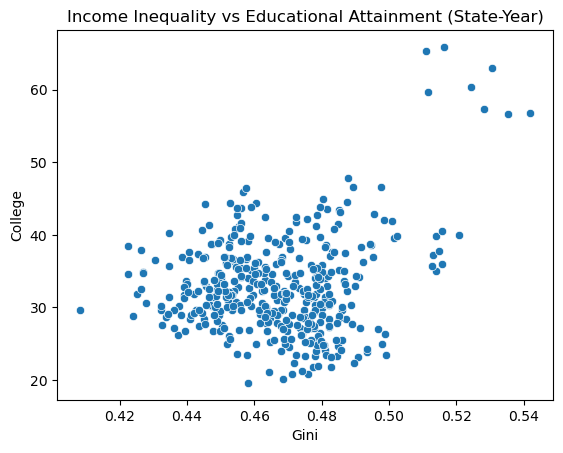

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=acs, x="Gini", y="College")
plt.title("Income Inequality vs Educational Attainment (State-Year)")
plt.show()

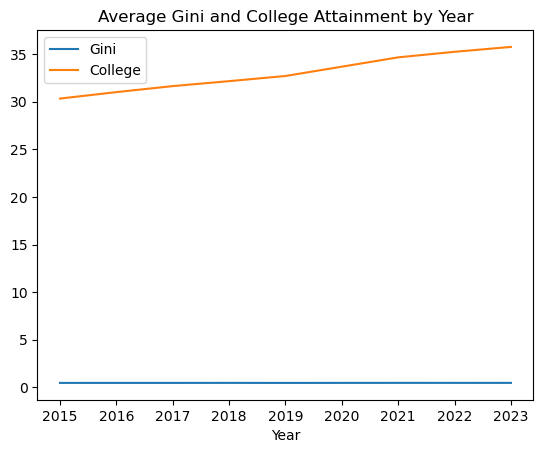

In [21]:
acs.groupby("Year")[["Gini","College"]].mean().plot()
plt.title("Average Gini and College Attainment by Year")
plt.show()

In [22]:
acs.head(10)

,State,state_fips,Year,Gini,College
0,Mississippi,28,2015,0.4759,20.8
1,Missouri,29,2015,0.4634,27.8
2,Montana,30,2015,0.4623,30.6
3,Nebraska,31,2015,0.4473,30.2
4,Nevada,32,2015,0.4548,23.6
5,New Hampshire,33,2015,0.4347,35.7
6,New Jersey,34,2015,0.4832,37.6
7,New Mexico,35,2015,0.4795,26.5
8,New York,36,2015,0.5138,35.0
9,North Carolina,37,2015,0.4776,29.4


In [23]:
state_abbrev = {
"Alabama":"AL","Alaska":"AK","Arizona":"AZ","Arkansas":"AR","California":"CA",
"Colorado":"CO","Connecticut":"CT","Delaware":"DE","District of Columbia":"DC",
"Florida":"FL","Georgia":"GA","Hawaii":"HI","Idaho":"ID","Illinois":"IL",
"Indiana":"IN","Iowa":"IA","Kansas":"KS","Kentucky":"KY","Louisiana":"LA",
"Maine":"ME","Maryland":"MD","Massachusetts":"MA","Michigan":"MI","Minnesota":"MN",
"Mississippi":"MS","Missouri":"MO","Montana":"MT","Nebraska":"NE","Nevada":"NV",
"New Hampshire":"NH","New Jersey":"NJ","New Mexico":"NM","New York":"NY",
"North Carolina":"NC","North Dakota":"ND","Ohio":"OH","Oklahoma":"OK",
"Oregon":"OR","Pennsylvania":"PA","Rhode Island":"RI","South Carolina":"SC",
"South Dakota":"SD","Tennessee":"TN","Texas":"TX","Utah":"UT","Vermont":"VT",
"Virginia":"VA","Washington":"WA","West Virginia":"WV","Wisconsin":"WI","Wyoming":"WY"
}

acs["State_abbr"] = acs["State"].map(state_abbrev)
acs.head()

,State,state_fips,Year,Gini,College,State_abbr
0,Mississippi,28,2015,0.4759,20.8,MS
1,Missouri,29,2015,0.4634,27.8,MO
2,Montana,30,2015,0.4623,30.6,MT
3,Nebraska,31,2015,0.4473,30.2,NE
4,Nevada,32,2015,0.4548,23.6,NV


In [24]:
acs.to_csv("cleaned_data/acs_income_education.csv", index=False)

In [25]:
acs.groupby("Year")[["Gini","College"]].mean()

,Gini,College
Year,,
2015,0.465675,30.333333
2016,0.466361,31.009804
2017,0.465949,31.641176
2018,0.468008,32.162745
2019,0.464165,32.703922
2021,0.470225,34.660784
2022,0.469410,35.245098
2023,0.467404,35.756863


%college

In [27]:
import pandas as pd
import requests

years = range(2015, 2024)

college_dfs = []

for y in years:
    
    # 跳过2020（没有acs1）
    if y == 2020:
        continue
        
    url = f"https://api.census.gov/data/{y}/acs/acs1/subject?get=NAME,S1501_C02_015E&for=state:*"
    
    r = requests.get(url)
    data = r.json()
    
    df = pd.DataFrame(data[1:], columns=data[0])
    
    df = df.rename(columns={
        "NAME":"State",
        "S1501_C02_015E":"College",
        "state":"state_fips"
    })
    
    df["Year"] = y
    
    college_dfs.append(df)

college = pd.concat(college_dfs, ignore_index=True)

college.head()

,State,College,state_fips,Year
0,Mississippi,20.8,28,2015
1,Missouri,27.8,29,2015
2,Montana,30.6,30,2015
3,Nebraska,30.2,31,2015
4,Nevada,23.6,32,2015


In [28]:
college["College"] = pd.to_numeric(college["College"], errors="coerce")
college["Year"] = pd.to_numeric(college["Year"], errors="coerce")

In [29]:
territories = {"60","66","69","72","78"}

college = college[~college["state_fips"].isin(territories)].copy()

In [30]:
college.head()

,State,College,state_fips,Year
0,Mississippi,20.8,28,2015
1,Missouri,27.8,29,2015
2,Montana,30.6,30,2015
3,Nebraska,30.2,31,2015
4,Nevada,23.6,32,2015


In [31]:
college.isna().sum()

State         0
College       0
state_fips    0
Year          0
dtype: int64

In [32]:
college["College"].describe()

count    408.000000
mean      32.939216
std        6.795553
min       19.600000
25%       28.675000
50%       32.050000
75%       36.425000
max       65.900000
Name: College, dtype: float64

In [33]:
college.duplicated(subset=["State","Year"]).sum()

np.int64(0)

In [34]:
college.to_csv("raw_data/acs_college_raw.csv", index=False)

In [35]:
college_clean = college[["State","Year","College"]]

college_clean.to_csv("cleaned_data/acs_college.csv", index=False)

In [36]:
acs = pd.merge(
    gini,
    college,
    on=["State","state_fips","Year"],
    how="inner"
)

In [37]:
acs.head()

,State,Gini,state_fips,Year,College
0,Mississippi,0.4759,28,2015,20.8
1,Missouri,0.4634,29,2015,27.8
2,Montana,0.4623,30,2015,30.6
3,Nebraska,0.4473,31,2015,30.2
4,Nevada,0.4548,32,2015,23.6


In [38]:
acs = acs[["State", "state_fips", "Year", "Gini", "College"]]

acs.head()

,State,state_fips,Year,Gini,College
0,Mississippi,28,2015,0.4759,20.8
1,Missouri,29,2015,0.4634,27.8
2,Montana,30,2015,0.4623,30.6
3,Nebraska,31,2015,0.4473,30.2
4,Nevada,32,2015,0.4548,23.6


In [39]:
len(acs)

408

In [40]:
acs.duplicated(subset=["State","Year"]).sum()

np.int64(0)

In [41]:
acs.isna().sum()

State         0
state_fips    0
Year          0
Gini          0
College       0
dtype: int64

In [42]:
import os
os.makedirs("cleaned_data", exist_ok=True)

In [43]:
acs.to_csv("cleaned_data/acs_state_year.csv", index=False)

In [44]:
print("ACS dataset shape:", acs.shape)
acs.head()

ACS dataset shape: (408, 5)


,State,state_fips,Year,Gini,College
0,Mississippi,28,2015,0.4759,20.8
1,Missouri,29,2015,0.4634,27.8
2,Montana,30,2015,0.4623,30.6
3,Nebraska,31,2015,0.4473,30.2
4,Nevada,32,2015,0.4548,23.6
